# H&E histological patch classification

Members: Théo, Jehan, Matthieu



## Imports and paths

Import the librairies that will be used :
- os for the path management
- shutil for copypath
- jolib to save and loads the models
- sklearn for the machine learning algorithms
- numpy and pandas for math and data
- skimage and PIL for image tinkering

We pre prepared and added the paths for the different folders and CSV files we will use later on.

In [87]:
import warnings
warnings.simplefilter("ignore")

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL as Image
from PIL import Image as PILImage

from skimage import color, exposure, feature, filters, io, measure, morphology, util
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#get the current root path of the program
CWD = os.getcwd()
ROOT_DIR = CWD

DATA_DIR = os.path.join(ROOT_DIR, 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'datasetjehan')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'tdatasetJehan')
QUALITY_DIR = os.path.join(DATA_DIR, 'quality_control')
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, 'features_train.csv')
MODEL_PATH = os.path.join(DATA_DIR, 'best_model.joblib')
FIG_DIR = os.path.join(DATA_DIR, 'figures')

N_EXAMPLES_PER_CLASS = 5
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
print(CWD)


/workspaces/cell_classification/src


## Part I/ Data exploration

We start by loading the CSV file and summarize the dataset. We added a quality control folder and finally we display the label distribution to have a better idea of the repartition of the dataset. Hence, it will help us to see if there is imbalance between the classes, and we prepare the folders we will use later.


Total samples: 400
Labels: ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']


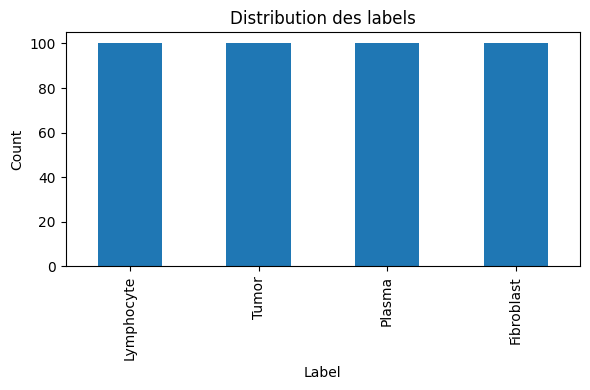

Imbalance ratio (max/min): 1.00


In [88]:
# loading of the CSV
train_df = pd.read_csv(TRAIN_CSV)

# global informations
num_samples = len(train_df)
label_names = sorted(train_df['Label'].unique())
label_counts = train_df['Label'].value_counts()

print(f'Total samples: {num_samples}')
print(f'Labels: {label_names}')

# label distribution plot
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar')
plt.title('Distribution des labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution.png'))
plt.show()

# balance ratio
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# quality control dir
os.makedirs(QUALITY_DIR, exist_ok=True)
for label in label_names:
    os.makedirs(os.path.join(QUALITY_DIR, str(label)),
                exist_ok=True)

def find_image_path(img_id, img_dir):
    #return the path for an existing file
    exts = ['.png', '.jpg', '.jpeg'] 
    for ext in exts:
        cand = os.path.join(img_dir, f'{img_id}{ext}')
        if os.path.exists(cand):
            return cand
    return None

# copy image per label
for _, row in train_df.iterrows():
    img_id = row['Image']
    label = row['Label']
    src_path = find_image_path(img_id, TRAIN_IMG_DIR)
    
    if src_path is None:
        continue
        
    dst_path = os.path.join(QUALITY_DIR, str(label), os.path.basename(src_path))
    
    if not os.path.exists(dst_path):
        shutil.copyfile(src_path, dst_path)


We can see first that there is 4 different labels: Fibroblast, lymphocyte, Plasma and Tumor. Those 4 labels has the exact same amount each, meaning that each class are perfectly balanced, moreover there is 400 total samples, which make this dataset really good for machine learning. It leaves enough images for both the training set and the testing set.
We chose not to remove pictures as there will be potentially similar one in the final dataset. 


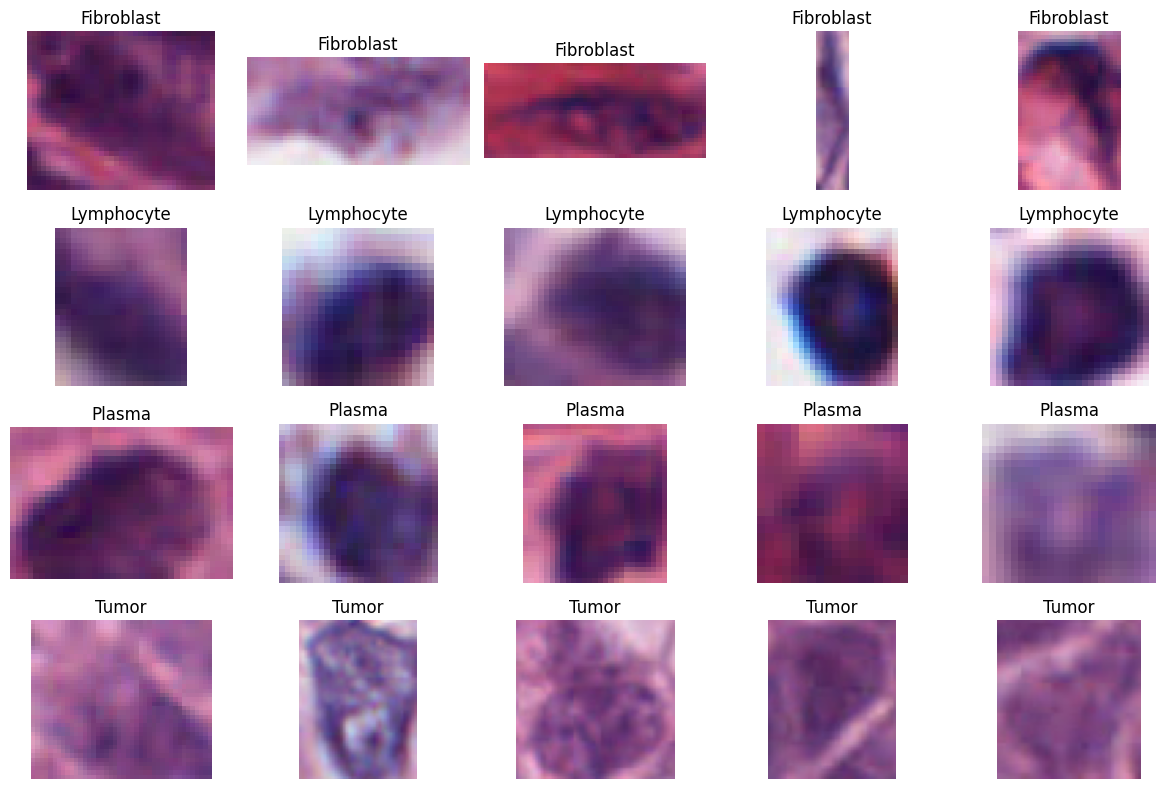

In [89]:
# exemple of each class

#prepare the random seed and the subplot space
np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(len(label_names),
                         N_EXAMPLES_PER_CLASS,
                         figsize=(12, 2 * len(label_names)))


#
for i, label in enumerate(label_names):
    subset = train_df[train_df['Label'] == label]
    sample_rows = subset.sample(
        n=min(N_EXAMPLES_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE
    )
    
    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = find_image_path(row['Image'],
                                  TRAIN_IMG_DIR)
        ax = axes[i, j] if len(label_names) > 1 else axes[j]
        ax.axis('off')
        if img_path is None:
            ax.set_title('Missing')
            continue

        img = io.imread(img_path)
        
        if img.ndim == 2:
            img = color.gray2rgb(img)
        
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        
        ax.imshow(img)
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'examples_grid.png'))
plt.show()


From a first glance, we can see few differences between the classes and already imagines which ones will be harder or easier to classify. For instance, the Lymphocyte is long and has a really distinctive shape compared to the other types which are really round such as the lymphocytes and the plasma. We cal also see that lymphocytes are especially dark, but some look simirlar to some pictures of plasma. However their colors do are a bit different, lyphocyte are more blue, where the plasma seems to have some tints of red and blue, and more variation in color within the plasma. The Tumor's seems bigger than the others with a different texture in it. I can also see that the tumor seems to have a different texture than the others. Finally, 

Through this first analyse, I predict that firbroblast and tumors will be the easiest to predict, wherease Plasma and lymphocyte whom can be similar will be harder.

## Part II/ feature extraction

From the last analysis, i saw multiple different features that seems relevent. 
- Area features: area ratio of the detected cell/tissue region.
- Shape features: eccentricity, compactness, or aspect ratio.
- Intensity features: mean grayscale intensity and dark pixel ratio.
- Color features: mean red intensity and mean blue intensity.
- Perimeter feature: perimeter of the detected cell/tissue region.

  

First of all, we start by creating with numpy some basics computer vision functions. 
we made 4 functions, first we need to loads the images. As we saw from the dataset, all the images are RGB so our function load them in rgb with the librairy PIL. 
Then as we will try to extract features based on the grayscale, we made a function creating a grayscale from the RGB using the formula saw in the first class of computer vision.
Thirdly, we made an otsu tresholding function to find automaticaly the right treshold to transform our grayscale image into a binary image. Otsu find the treshold by maximising the difference between the foreground and the background of the intensity.
Finnaly, we made a function that find the cell/tissue we want to see thanks to the previous functions. However this is not perfect as there might be object in the background that the tresholding saw as foreground. Meaning that the img_binary will probably take both the tissues and some noise.

In [90]:
from PIL import Image as PILImage


def load_rgb_image(path):
    img = PILImage.open(path).convert('RGB')
    return np.asarray(img, dtype=np.uint8)


#rgb to grey scale (formula from the computer vision class)
def grayscale_image(rgb):
    rgb_float = rgb.astype(np.float32) / 255.0
    r = rgb_float[:, :, 0]
    g = rgb_float[:, :, 1]
    b = rgb_float[:, :, 2]
    return 0.299 * r + 0.587 * g + 0.114 * b


#otsu thresohding
def otsu_threshold_np(gray):
    gray_uint8 = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    hist = np.bincount(gray_uint8.ravel(), minlength=256).astype(np.float64)
    total = gray_uint8.size

    pixel_values = np.arange(256, dtype=np.float64)
    sum_total = np.dot(pixel_values, hist)
    sum_background = 0.0
    weight_background = 0.0
    best_variance = -1.0
    best_threshold = 0

    for threshold in range(256):
        weight_background += hist[threshold]
        if weight_background == 0:
            continue

        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break

        sum_background += threshold * hist[threshold]
        mean_background = sum_background / weight_background
        mean_foreground = (
            sum_total - sum_background
        ) / weight_foreground

        between_variance = (
            weight_background
            * weight_foreground
            * (mean_background - mean_foreground) ** 2
        )

        if between_variance > best_variance:
            best_variance = between_variance
            best_threshold = threshold

    return best_threshold / 255.0


#apply the previous functions to create a binary image
def tissue_img_binary(rgb):
    gray = grayscale_image(rgb)
    threshold = otsu_threshold_np(gray)
    img_binary = gray < threshold

    ratio = img_binary.mean()
    if ratio < 0.01 or ratio > 0.95:
        img_binary = gray < np.percentile(gray, 90)

    return img_binary.astype(bool)


### Area and shape features

The features linked to the area and the shape of the tissues/cells that we decided to use are : 
- first the area ratio which is the ratio between the object and the size of the picture. We think this feature is interesting as the pictures with the fibroblasts seems to have a lesser ratio of space taken by the fibroblast than the others. In contrary, the tumors seems to take more space in the pictures than the other types.
- In second, the perimeter ratio which is the amount of the perimeter compared to the number inside of the pixel. this feature can sense the iregular shapes as the higher the ratio is, the more iregular or complexe the shape should be. As said in the previous pre analysis, the tumors and fibroblast seems to have more irregular shapes than the lymphocites and the plasma, making this feature possibly relevent.
- thirdly, the compactness and the eccentricity. The former one show how compact is the shape, the most compact being the circle, this gives a good feature to find the lymphocytes and plasma. The latter shows how long the form is, being therefore particullarly relevent for the fibroblast.
- finally, the shape aspect ratio shows the ratio between the height and withd of the box around the cell, and the extent represent how much space does the cell take in the picture. 

In [91]:
def area_features(img_binary):
    area = float(np.sum(img_binary))
    area_ratio = area / img_binary.size

    return {
        'area_ratio': float(area_ratio),
    }


def perimeter_np(img_binary):
    img_binary_uint8 = img_binary.astype(np.uint8)

    up = np.pad(img_binary_uint8[:-1, :], ((1, 0), (0, 0)))
    down = np.pad(img_binary_uint8[1:, :], ((0, 1), (0, 0)))
    left = np.pad(img_binary_uint8[:, :-1], ((0, 0), (1, 0)))
    right = np.pad(img_binary_uint8[:, 1:], ((0, 0), (0, 1)))

    edge = (img_binary_uint8 == 1) & (
        (up == 0) | (down == 0) | (left == 0) | (right == 0)
    )

    return float(np.sum(edge))


def shape_features(img_binary):
    height, width = img_binary.shape
    total_pixels = height * width
    coords = np.column_stack(np.where(img_binary))
    eps = 1e-8

    rows = coords[:, 0]
    cols = coords[:, 1]

    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()

    shape_height = max(row_max - row_min + 1, 1)
    shape_width = max(col_max - col_min + 1, 1)
    shape_area = shape_height * shape_width

    area = float(np.sum(img_binary))
    perimeter = perimeter_np(img_binary)

    if perimeter > 0:
        compactness = 4.0 * np.pi * area / (perimeter ** 2)
    else:
        compactness = 0.0

    if len(coords) >= 2:
        centered = coords.astype(np.float64) - coords.mean(axis=0)
        cov = np.cov(centered.T) + eps * np.eye(2)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.maximum(eigvals, eps)
        eccentricity = np.sqrt(1.0 - eigvals.min() / eigvals.max())
    else:
        eccentricity = 0.0

    shape_aspect_ratio = shape_width / max(shape_height, 1)
    shape_extent = area / max(shape_area, 1)

    return {
        'perimeter_ratio': float(perimeter / total_pixels),
        'compactness': float(compactness),
        'eccentricity': float(eccentricity),
        'shape_aspect_ratio': float(shape_aspect_ratio),
        'shape_extent': float(shape_extent),
    }

### Intensity and color features

The features linked to the intensity and the color we choose are : 
- firstly, we chose the extract many information about the grayscale such as the mean intensity, the standart deviation and the dark pixel ratio. We previously saw in the pre analysis that the lymphocyte are particularly dark, and that the plasma too, but seems to be less. Therefore we hope for these features to be able to discriminate a part of the lymphocyte from the plasma.
- Secondly, we chose to look at the red and blue ratio. We also saw previously that the lymphocytes tends to have more intensity in blue than the plasma who tends to have both a high intensity in blue and red. Therefore chose to exctract the mean of both the red and blue as well as the ratio blue/red. As we did not see any colors truly related to the green, we chose not to include it.
- finally, we saw that lymphocytes seems to contrast a lot compared to their background, so we wanted to extract contrast features in order to better differentiate it to the plasma. but we also saw that there was different types of textures for the cells, especially for the tumors, so we decided to use look at the contrast within the object too.


In [92]:
#return the values inside the img_binary or all the values if the img_binary is empty
def img_binaryed_values(channel, img_binary):
    if np.any(img_binary):
        return channel[img_binary].reshape(-1)
    return channel.reshape(-1)

def texture_contrast_np(gray, img_binary):
    if gray.size == 0:
        return 0.0

    horizontal = (gray[:, 1:] - gray[:, :-1]) ** 2
    vertical = (gray[1:, :] - gray[:-1, :]) ** 2

    img_binary_horizontal = img_binary[:, 1:] | img_binary[:, :-1]
    img_binary_vertical = img_binary[1:, :] | img_binary[:-1, :]

    values = []
    if np.any(img_binary_horizontal):
        values.append(horizontal[img_binary_horizontal])
    if np.any(img_binary_vertical):
        values.append(vertical[img_binary_vertical])

    if len(values) == 0:
        return 0.0

    return float(np.mean(np.concatenate(values)))
    
def object_background_contrast(gray, img_binart):
    if gray.size == 0:
        return 0.0

    object_pixels = gray[img_binart]
    background_pixels = gray[~img_binart]

    if object_pixels.size == 0 or background_pixels.size == 0:
        return 0.0

    object_mean = np.mean(object_pixels)
    background_mean = np.mean(background_pixels)

    return float(abs(object_mean - background_mean))

In [93]:
#get the features based on intensity / colors
def intensity_features(rgb, img_binary):
    rgb_float = rgb.astype(np.float32) / 255.0
    gray = grayscale_image(rgb)
    gray_flat = gray.reshape(-1)

    p25, p50, p75 = np.percentile(gray_flat, [25, 50, 75])
    values_gray = img_binaryed_values(gray, img_binary)

    red_channel = rgb_float[:, :, 0]
    blue_channel = rgb_float[:, :, 2]

    values_r = img_binaryed_values(red_channel, img_binary)
    values_b = img_binaryed_values(blue_channel, img_binary)
    
    blue_red_ratio = np.mean(values_b / (values_r + 1e-6))
    texture_contrast = texture_contrast_np(gray, img_binary)
    object_to_background_contrast = object_background_contrast(gray, img_binary)
    
    hue = rgb_to_hue(rgb_float)
    hue_values = hue[img_binary]
    return {
        'gray_mean': float(np.mean(values_gray)),
        'gray_std': float(np.std(gray_flat)),
        'dark_pixel_ratio': float(np.mean(gray < 0.5)),
        'red_mean': float(np.mean(values_r)),
        'blue_mean': float(np.mean(values_b)),
        'red_std': float(np.std(values_r)),
        'blue_std': float(np.std(values_b)),
        'blue_red_ratio': float(blue_red_ratio),
        'texture_contrast': float(texture_contrast),
        'object_background_contrast': object_to_background_contrast,
    }


###  Extract the features for each pictures

For every pictures, we need to load it, then get the binary and rgb versions of this image, and then apply all the features exctrations functions previously defined then map all the returned dictionnaries into one big dictionnary that will be used in for the visualisation of the features.
The function build_feature_table loop through the images and their corresponding labels to map each features extracted from the images with the label of the corresponfing image.

In [94]:
#load the image and extract the features
def extract_features_from_path(img_path):
    rgb = load_rgb_image(img_path)
    img_binary = tissue_img_binary(rgb)

    features_dict = {}
    features_dict.update(area_features(img_binary))
    features_dict.update(shape_features(img_binary))
    features_dict.update(intensity_features(rgb, img_binary))
    return features_dict


def build_feature_table(df, image_dir, include_labels=True):
    rows = []
    n_total = len(df)

    #as a reminder, df is the dataframe containing the training dataset
    for count, (_, row) in enumerate(df.iterrows(), start=1):
        img_id = row['Image']
        img_path = find_image_path(img_id, image_dir)

        if img_path is None:
            print(f'Missing image: {img_id}')
            continue

        #for the debugging 
        try:
            features_row = extract_features_from_path(img_path)
        except Exception as exc:
            print(f'Error with {img_id}: {exc}')
            continue

        features_row['Image'] = img_id
        if include_labels:
            features_row['Label'] = row['Label']
        rows.append(features_row)

        if count % 50 == 0 or count == n_total:
            print(f'Processed {count}/{n_total} images')

    return pd.DataFrame(rows)


features_df = build_feature_table(train_df, TRAIN_IMG_DIR, include_labels=True,)
features_df.to_csv(FEATURES_TRAIN_CSV, index=False) #create a CSV with the informations
print(f'Saved features to: {FEATURES_TRAIN_CSV}')
features_df.head()


Missing image: 0
Missing image: 1
Missing image: 2
Missing image: 3
Missing image: 4
Missing image: 5
Missing image: 6
Missing image: 7
Missing image: 8
Missing image: 9
Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Saved features to: /workspaces/cell_classification/src/data/features_train.csv


,area_ratio,perimeter_ratio,compactness,eccentricity,shape_aspect_ratio,shape_extent,gray_mean,gray_std,dark_pixel_ratio,red_mean,blue_mean,red_std,blue_std,blue_red_ratio,texture_contrast,object_background_contrast,Image,Label
0,0.578776,0.086531,0.792947,0.657253,1.032258,0.714718,0.485455,0.134257,0.297143,0.547305,0.629569,0.068317,0.066971,1.156542,0.001144,0.236168,10,Fibroblast
1,0.558442,0.083333,1.093649,0.805596,1.333333,0.671875,0.141705,0.123694,0.975108,0.216887,0.249696,0.061115,0.043228,1.207659,0.000802,0.218221,11,Lymphocyte
2,0.660256,0.101282,1.036962,0.622712,0.785714,0.836039,0.198216,0.259979,0.687179,0.226796,0.356109,0.088410,0.096879,1.669660,0.002505,0.510092,12,Lymphocyte
3,0.543129,0.130874,0.237047,0.567639,1.000000,0.543129,0.418743,0.086542,0.604997,0.505912,0.572038,0.046450,0.041934,1.136017,0.000453,0.138000,13,Tumor
4,0.618386,0.146825,0.238405,0.870907,2.160000,0.692593,0.624591,0.099473,0.023148,0.699323,0.725369,0.059425,0.045264,1.040537,0.000797,0.166469,14,Fibroblast


### Feature visualization

Here, we will uses box plots as it helps identify discriminative features. Moreoever, the correlation matrix helps spot redundant features. Correlated features does not necesserly needs to all appear in the chosen features for the machine learning part.
To compare more easily each plots we will use the subplots so as to have a more compact and readable sets of box plots.


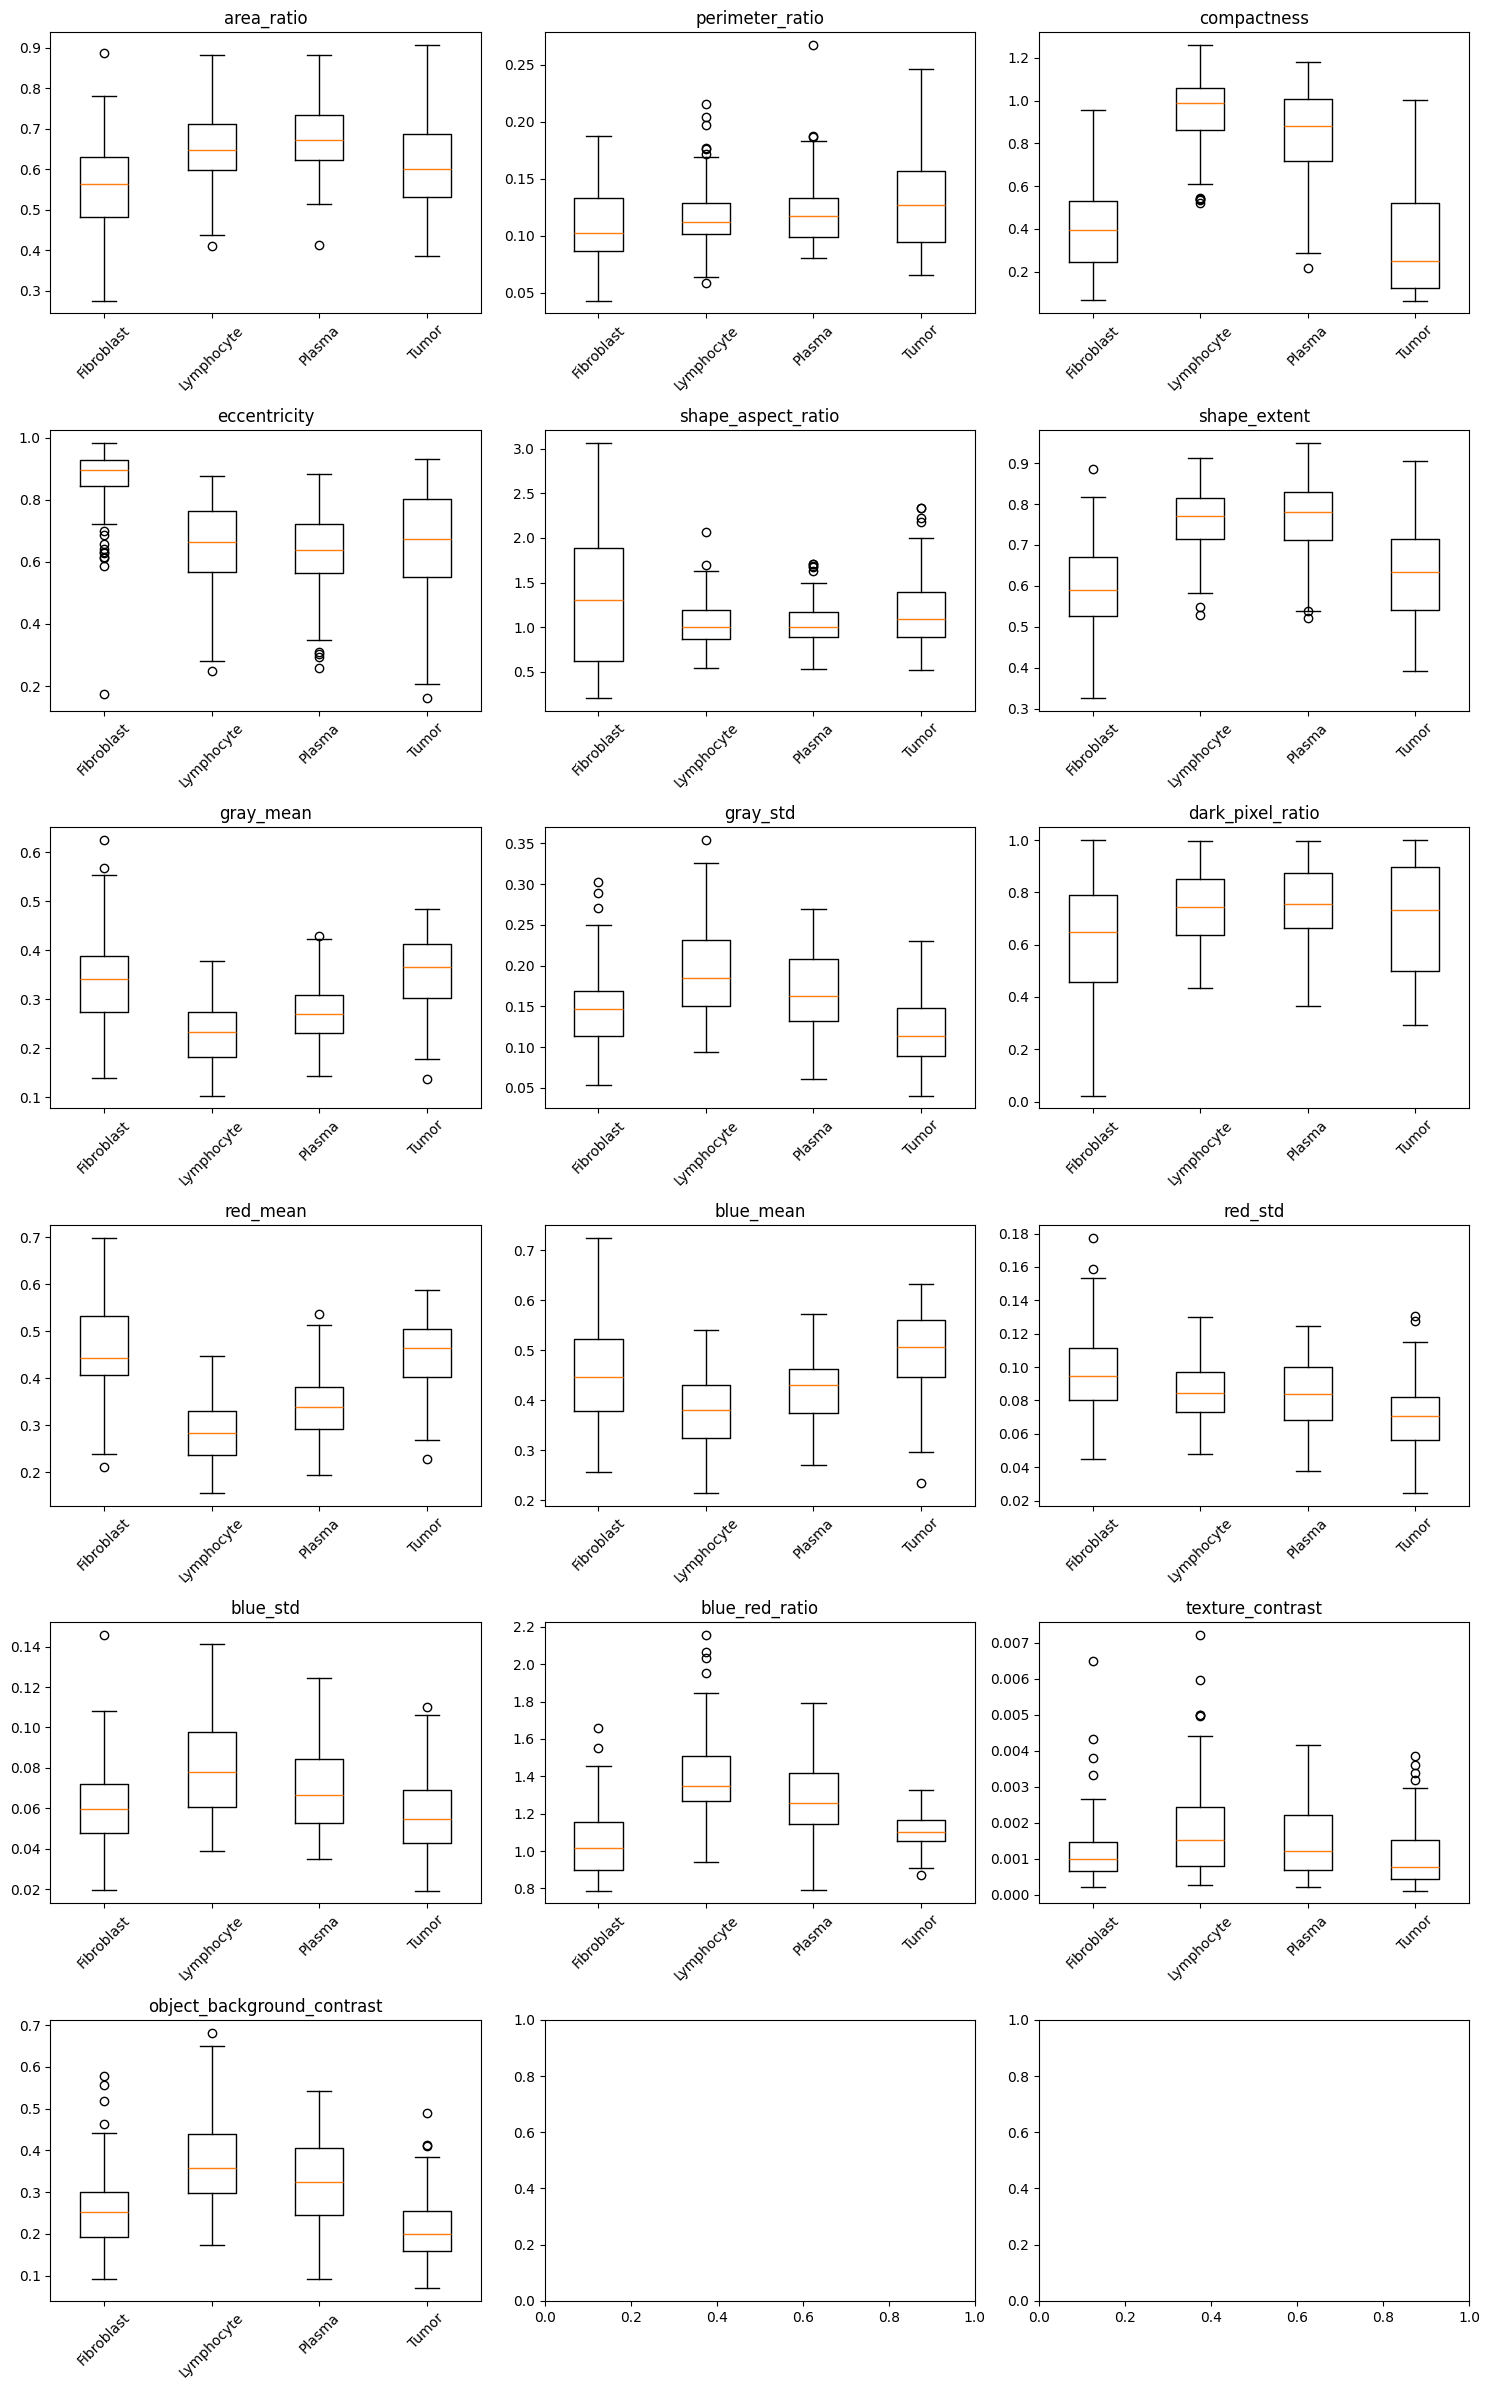

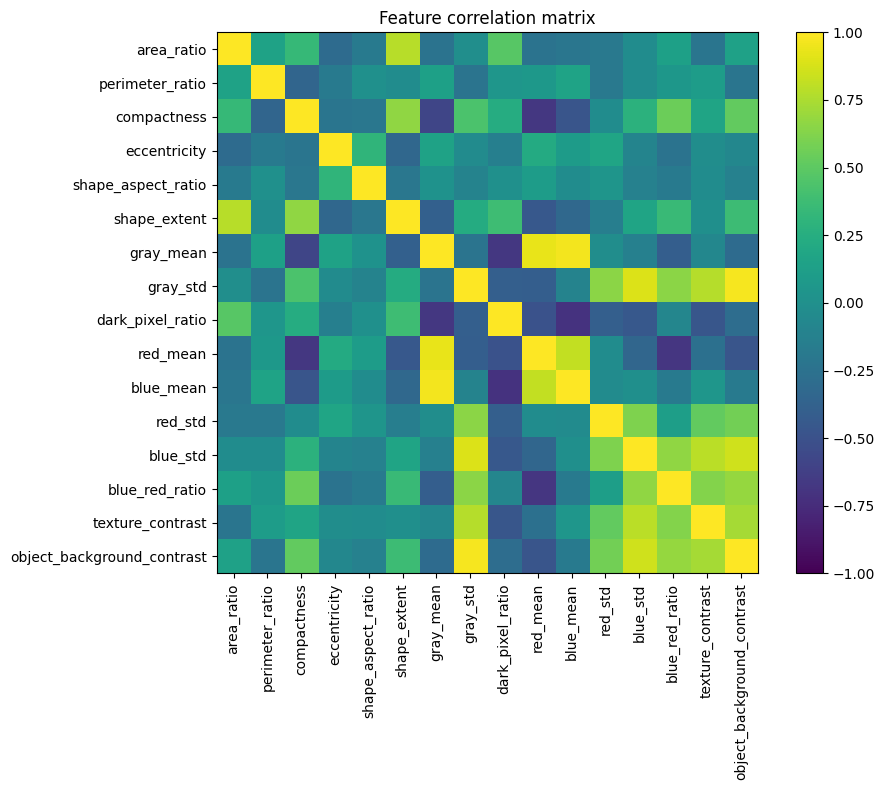

Pairs that has 0.9 of correlation:
gray_mean / red_mean: 0.930
gray_mean / blue_mean: 0.963
gray_std / object_background_contrast: 0.974


In [95]:
#get the feature column
feature_cols = [
    col for col in features_df.columns
    if col not in ['Image', 'Label']
]

#create the subplot
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.ravel() #we flatten the array in otder to make the iterations easier afterward

#plot a boxplot for every features
for i, feat_name in enumerate(feature_cols):
    data = [
        features_df[features_df['Label'] == lab][feat_name].dropna().values
        for lab in label_names
    ]

    axes[i].boxplot(data, labels=[str(lab) for lab in label_names])
    axes[i].set_title(feat_name)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_boxplots_grid.png'))
plt.show()


#make the correlation matrix and the plot it
corr = features_df[feature_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_corr.png'))
plt.show()

#detect the features that are correlated to each other for more than 90%
high_corr_pairs = []
for i, feat_a in enumerate(feature_cols):
    for feat_b in feature_cols[i + 1:]:
        value = corr.loc[feat_a, feat_b]
        if abs(value) > 0.90:
            high_corr_pairs.append((feat_a, feat_b, value))
print('Pairs that has 0.9 of correlation:')
for feat_a, feat_b, value in high_corr_pairs:
    print(f'{feat_a} / {feat_b}: {value:.3f}')

Thanks to those plots, we can better understand which features are relevent to use for the next step.
- area_ratio : We can see that this ratio show a noticeable difference between the fibroblast and the others as well a slighter difference for the tumor. therefore it would be a normal or good feature to use.
- perimeter ratio : This ratio show very little difference on the mean point and the standarts deviations boxes between the 4 classes, so it is not useful to use it.
- compactness : It can discriminate extremely well the fibroblast and the tumor with the other two on average, making it a great feature to use.
-  eccentricity :  This feature can also discriminates very well the fibroblast with the other 3 types, therefore we will probably use it.
-  shape_aspect_ratio : This feature show too much overlapping, making it not relevent to use.
-  shape_extent : This feature show a clear differenciation between the fibroblast and tumors against the plasma and lymphocyte.
-  gray_mean: This feature show a difference between  darker lymphocytes from brighter fibroblast and tumor images.
-  gray_std and object_background_contrast : Those features shows intensity variability information but are highly correlated with each other (0.974). So we will probably keep one of both features
-  Dark_pixel_ratio : This feature show little to no differentiation between the 4 classes, making it not relevent to use.
-  Red mean, blue mean, gray_mean : those features are highly correlated to each other, but all shows good differentiations between the classes, therefore we will use the one who shows the greater differentiation which is the red_mean feature.
-  red_std : This feature shows moderate differences between classes but does not give a strong separation, therefore we are not sure if we will use it or not.
-  blue_std : this feature has still a lot of overlap, but is however still better than red_std, therefore it might be relevent.
-  blue_red_ratio: This feature is really good to separate the tumors and fribroblast with the lymphocyte and plasma cells, therefore it is a relevent feature to use.
-  texture_contrast : Finally, this feature has too much overlapping between the classes to be relevent to use.

## Part III — Machine learning training

This part uses `scikit-learn`. The pipeline includes:

1. removal of constant features,
2. imputation of missing values,
3. feature normalization,
4. univariate feature selection,
5. hyperparameter tuning by grid search,
6. stratified cross-validation.

The project asks for at least two classification algorithms studied during the
course. Here we compare:

- **Logistic Regression** with the `lbfgs` solver,
- **SGDClassifier**, optimized with stochastic gradient descent,
- **K-Nearest Neighbors**, a classical supervised classification baseline.


In [81]:
ml_df = pd.read_csv(FEATURES_TRAIN_CSV).dropna(subset=["Label"])

selected_feature_cols = [
    "area_ratio",
    "perimeter_ratio",
    "compactness",
    "eccentricity",
    "shape_aspect_ratio",
    "shape_extent",
    "gray_std",
    "dark_pixel_ratio",
    "red_mean",
    "green_mean",
    "blue_mean",
    "red_std",
    "blue_std",
    "blue_red_ratio",
    "texture_contrast",
]

missing_features = [
    col for col in selected_feature_cols
    if col not in ml_df.columns
]
if len(missing_features) > 0:
    raise ValueError(f"Missing selected features: {missing_features}")

feature_cols = selected_feature_cols
X = ml_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = ml_df["Label"].values

n_features = len(feature_cols)
candidate_k_values = [8, 11, 14, n_features]
k_values = sorted(set(k for k in candidate_k_values if k <= n_features))

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
]

scoring_metric = "f1_weighted"
model_results = []
trained_searches = {}


def evaluate_predictions(model_name, y_true, y_pred, best_score, best_params):
    """Return the requested classification metrics."""
    return {
        "model": model_name,
        "best_cv_f1_weighted": float(best_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "best_params": best_params,
    }


def run_grid_model(model_name, classifier, param_grid):
    """Tune a model with GridSearchCV, then report CV predictions."""
    pipeline = Pipeline(base_steps + [("clf", classifier)])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring_metric,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X, y)

    # Cross-validated predictions using the best tuned pipeline.
    # This keeps the preprocessing inside each fold.
    preds = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv,
        n_jobs=-1,
    )

    result = evaluate_predictions(
        model_name=model_name,
        y_true=y,
        y_pred=preds,
        best_score=search.best_score_,
        best_params=search.best_params_,
    )

    cm = confusion_matrix(y, preds, labels=label_names)
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )
    display_obj.plot(xticks_rotation=30)
    plt.title(f"Cross-validated confusion matrix: {model_name}")
    plt.tight_layout()
    fig_name = f"confusion_matrix_{model_name}.png"
    plt.savefig(os.path.join(FIG_DIR, fig_name))
    plt.show()

    return result, search


print("Selected features used for machine learning:")
for feature in feature_cols:
    print("-", feature)

print("\nNumber of selected features:", n_features)
print("Feature-selection k values tested:", k_values)

ValueError: Missing selected features: ['green_mean']

### SVM

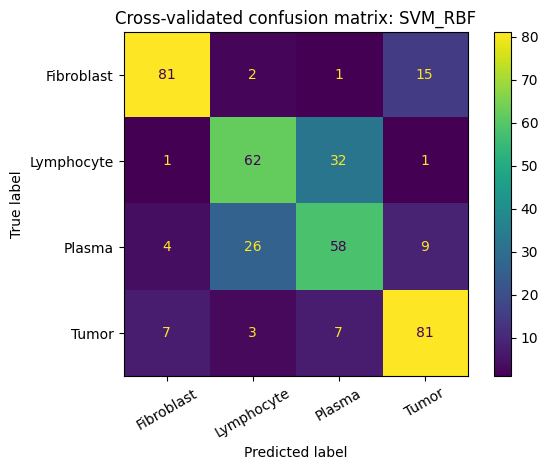

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,SVM_RBF,0.721767,0.723077,0.722121,0.724412,0.723077,0.723183,"{'clf__C': 100.0, 'clf__gamma': 0.01, 'select_..."


In [53]:
svm_classifier = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

svm_param_grid = {
    "select__k": k_values,
    "clf__C": [0.1, 1.0, 10.0, 100.0],
    "clf__gamma": ["scale", 0.01, 0.1, 1.0],
}

svm_result, svm_search = run_grid_model(
    "SVM_RBF",
    svm_classifier,
    svm_param_grid,
)

model_results.append(svm_result)
trained_searches["SVM_RBF"] = svm_search
display(pd.DataFrame([svm_result]))

### Random Forest


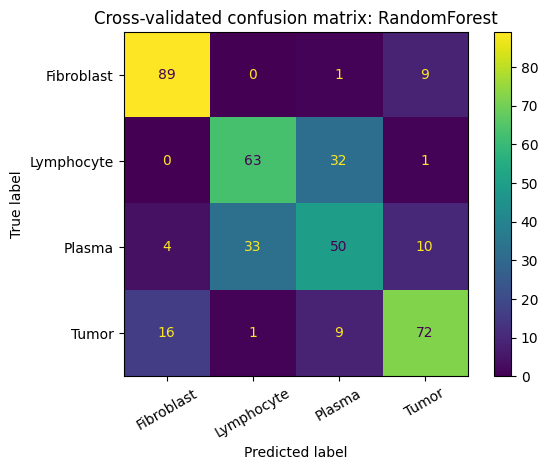

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,RandomForest,0.699547,0.702564,0.701349,0.69897,0.702564,0.699977,"{'clf__max_depth': 12, 'clf__max_features': 's..."


In [54]:
rf_classifier = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_param_grid = {
    "select__k": k_values,
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 4, 8, 12],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", None],
}

rf_result, rf_search = run_grid_model(
    "RandomForest",
    rf_classifier,
    rf_param_grid,
)

model_results.append(rf_result)
trained_searches["RandomForest"] = rf_search
display(pd.DataFrame([rf_result]))

### KNN

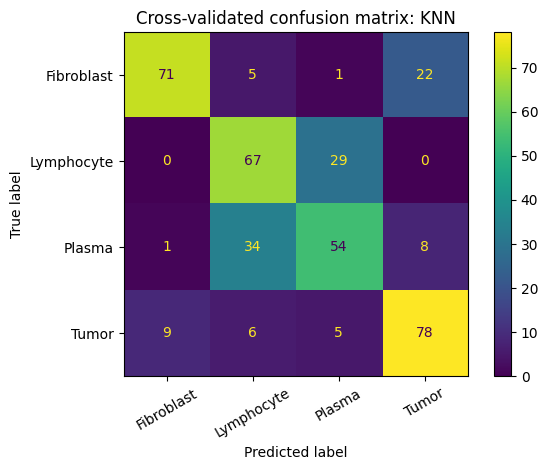

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,KNN,0.691785,0.692308,0.691927,0.702149,0.692308,0.693544,"{'clf__n_neighbors': 9, 'clf__p': 2, 'clf__wei..."


In [55]:
knn_classifier = KNeighborsClassifier()

knn_param_grid = {
    "select__k": k_values,
    "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

knn_result, knn_search = run_grid_model(
    "KNN",
    knn_classifier,
    knn_param_grid,
)

model_results.append(knn_result)
trained_searches["KNN"] = knn_search
display(pd.DataFrame([knn_result]))

### logistic regression with L-BFGS

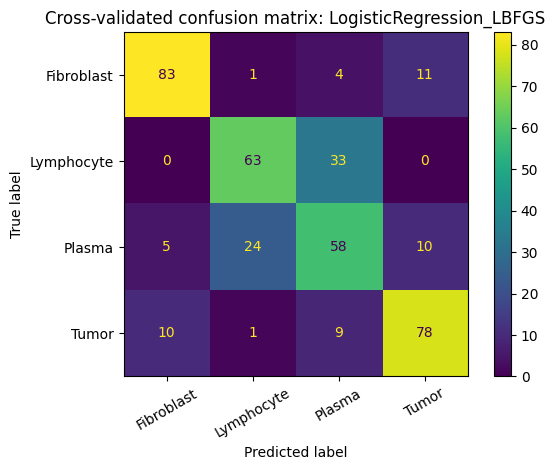

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,LogisticRegression_LBFGS,0.723252,0.723077,0.722123,0.725924,0.723077,0.724075,"{'clf__C': 100.0, 'select__k': 16}"


In [56]:
logreg_classifier = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
    solver="lbfgs",
)

logreg_param_grid = {
    "select__k": k_values,
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

logreg_result, logreg_search = run_grid_model(
    "LogisticRegression_LBFGS",
    logreg_classifier,
    logreg_param_grid,
)

model_results.append(logreg_result)
trained_searches["LogisticRegression_LBFGS"] = logreg_search
display(pd.DataFrame([logreg_result]))

## Part IV — Prediction on the future test set

This code is ready for the test phase. When the test image folder becomes
available, it extracts the same features, applies the selected model, and saves
`test.csv` with the same column structure as `train.csv`: `Image`, `Label`.


In [57]:
def make_test_dataframe(test_img_dir):
    """Create a dataframe containing test image identifiers."""
    image_files = [
        file_name for file_name in os.listdir(test_img_dir)
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    image_files = sorted(image_files)
    image_ids = [os.path.splitext(file_name)[0] for file_name in image_files]
    return pd.DataFrame({'Image': image_ids})


def predict_test_set(test_img_dir, output_csv):
    """Extract test features and save predicted labels."""
    if not os.path.exists(test_img_dir):
        print('Test directory not found. No prediction file was created.')
        return None

    saved = joblib.load(MODEL_PATH)
    trained_model = saved['model']
    saved_feature_cols = saved['feature_cols']

    test_df = make_test_dataframe(test_img_dir)
    test_features_df = build_feature_table(
        test_df,
        test_img_dir,
        include_labels=False,
    )

    for col in saved_feature_cols:
        if col not in test_features_df.columns:
            test_features_df[col] = 0.0

    X_test = test_features_df[saved_feature_cols].values
    predictions = trained_model.predict(X_test)

    output_df = pd.DataFrame({
        'Image': test_features_df['Image'].values,
        'Label': predictions,
    })
    output_df.to_csv(output_csv, index=False)
    print(f'Saved predictions to: {output_csv}')
    return output_df


TEST_OUTPUT_CSV = os.path.join(DATA_DIR, 'test.csv')

if os.path.exists(TEST_IMG_DIR):
    test_predictions = predict_test_set(TEST_IMG_DIR, TEST_OUTPUT_CSV)
else:
    print('Test image folder is not available yet.')


Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Saved predictions to: /workspaces/cell_classification/src/data/test.csv


## Final checklist before submission

- Restart the kernel and run all cells.
- Check that no error message remains.
- Complete the short written analyses after the figures.
- Verify that `features_train.csv`, `best_model.joblib`, and `test.csv` are
  created when the corresponding folders exist.
- Keep the notebook filename simple, with no spaces or special characters.
